## 1. Import Libraries

Import the Python libraries required for data loading, analysis, and visualization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

Load the telecom customer churn dataset and check its size.


In [2]:
df = pd.read_csv("telecom_customer_churn_eda-1.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 22


## 3. Initial Data Inspection

Preview the first rows to understand the dataset structure and variables.


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnReason
0,CUST100000,Male,0,No,No,66,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,47.18,2932.79,No,Not applicable
1,CUST100001,Female,1,No,No,24,Yes,No,Fiber optic,No,...,No,No,No,Two year,Yes,Electronic check,84.69,2243.11,Yes,Price too high
2,CUST100002,Male,0,No,No,60,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Bank transfer (automatic),48.51,2862.02,No,Not applicable
3,CUST100003,Male,0,Yes,No,25,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,29.72,741.43,No,Not applicable
4,CUST100004,Male,0,Yes,No,33,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,39.78,1268.06,Yes,Price too high


### Dataset Information

Check column names, data types, and non-null counts.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Missing Values

Identify columns containing missing values.


In [5]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

MonthlyCharges    12
TotalCharges      25
ChurnReason        8
dtype: int64


### Duplicate Records

Check whether duplicate rows are present.


In [6]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


### Numerical Data Types

Verify the data types of the main numerical charge columns before cleaning.


In [7]:
print(df[["MonthlyCharges", "TotalCharges"]].dtypes)

MonthlyCharges    float64
TotalCharges      float64
dtype: object


## 4. Data Cleaning

Fill missing numerical values using the median so that the dataset can be used for analysis without dropping customer records unnecessarily.


In [8]:
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(
    df["MonthlyCharges"].median()
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Missing MonthlyCharges:", df["MonthlyCharges"].isnull().sum())
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Missing MonthlyCharges: 0
Missing TotalCharges: 0


### Clean Churn Reasons

Replace missing churn reasons with `Not Available` so the churn-reason analysis can be performed without losing records.


In [9]:
df["ChurnReason"] = df["ChurnReason"].fillna("Not Available")

print("Missing ChurnReason:", df["ChurnReason"].isnull().sum())

Missing ChurnReason: 0


### Verify Missing Values

Confirm that the dataset contains no remaining missing values.


In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## 5. Descriptive Statistics

Review summary statistics for numerical variables.


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.153486,36.319466,55.680398,2021.880043
std,0.360481,21.024165,18.401726,1394.139215
min,0.000000,0.000000,2.000000,0.000000
25%,0.000000,18.000000,42.465000,879.595000
50%,0.000000,37.000000,56.270000,1823.710000
75%,0.000000,54.000000,69.350000,2954.650000
max,1.000000,72.000000,105.390000,7006.770000


## 6. Overall Churn Distribution

Measure the number and percentage of customers who churned versus those who did not.


In [12]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)
print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn
No     5185
Yes    1858
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.62
Yes    26.38
Name: proportion, dtype: float64


### Churn Distribution

Visualize the overall churn distribution.


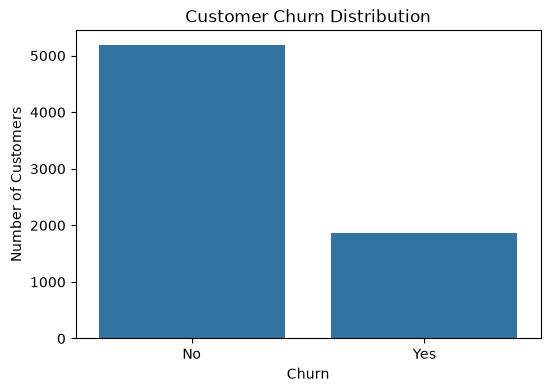

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## 7. Churn by Customer Characteristics and Services

Compare churn across contract type, internet service, payment method, gender, and senior-citizen status.


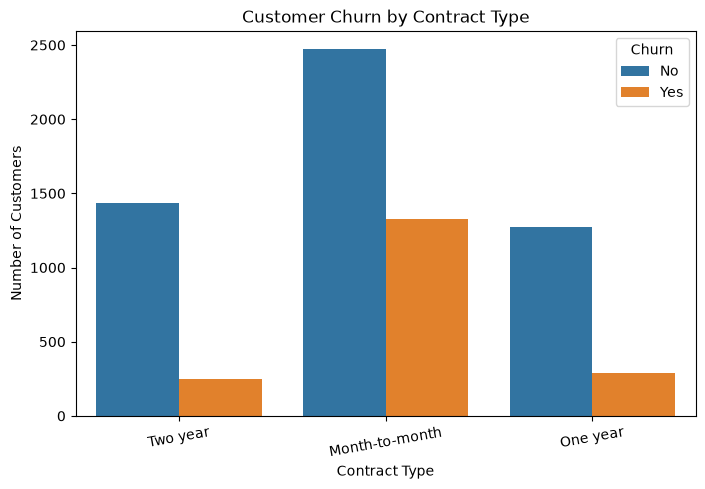

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=10)
plt.show()

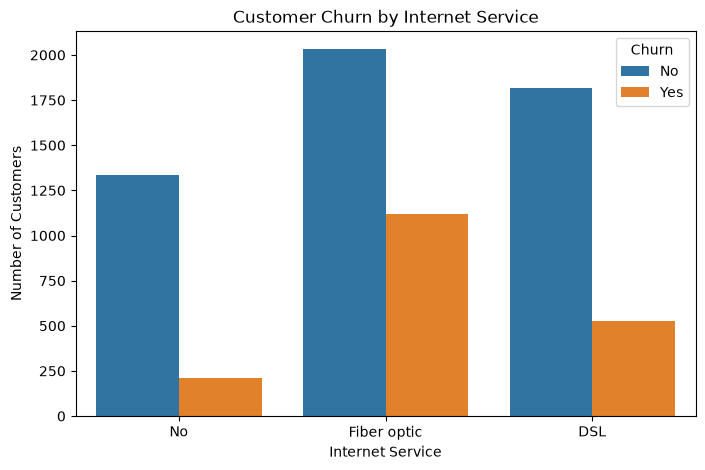

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

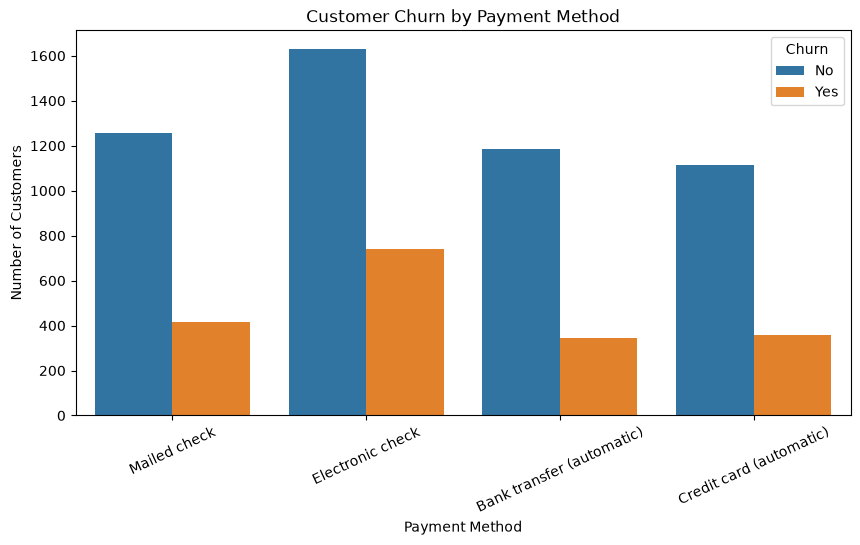

In [16]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.show()

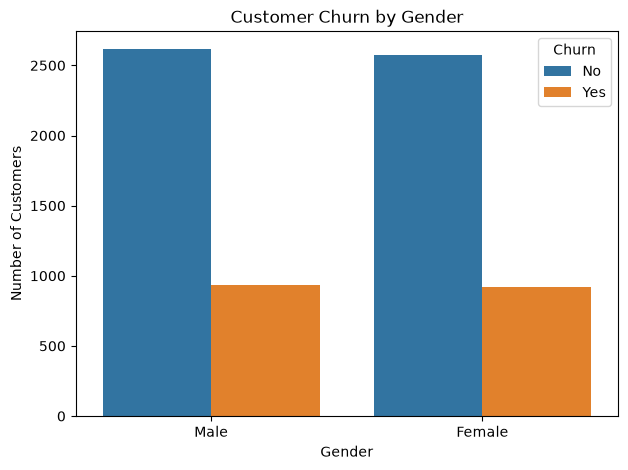

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

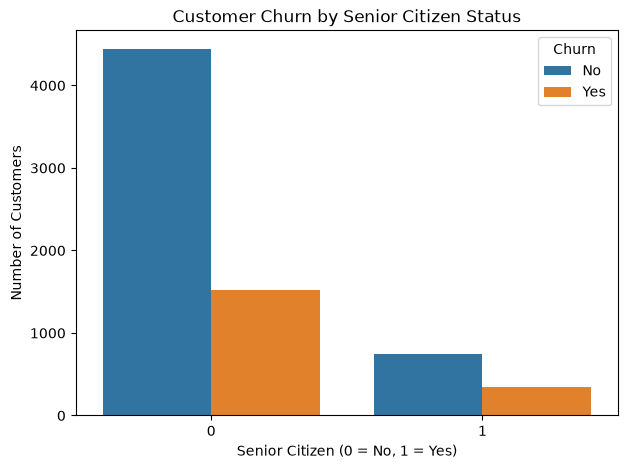

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

### Churn by Tenure

Examine how customer tenure is distributed across churn status.


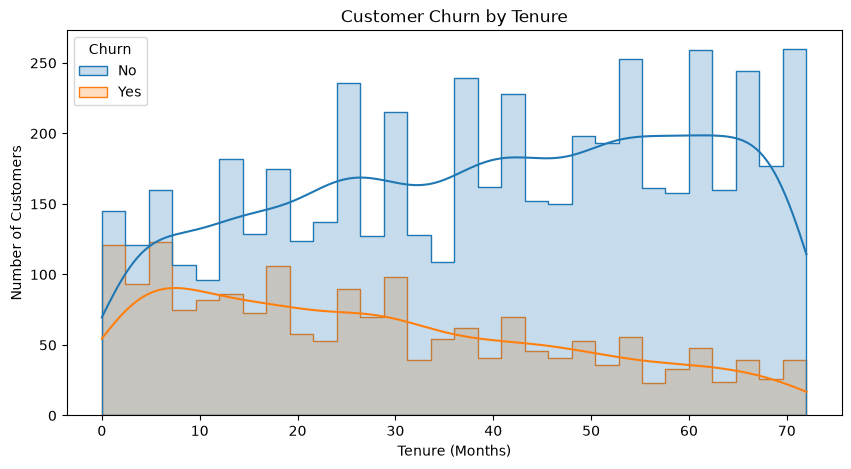

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

### Monthly Charges by Churn

Compare monthly charges between churned and non-churned customers.


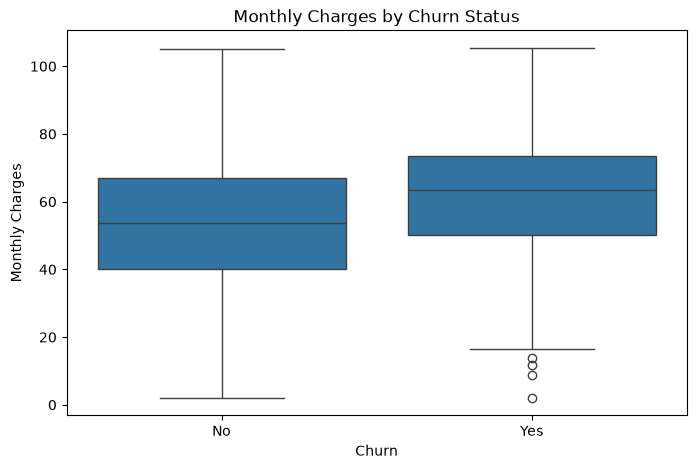

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## 8. Correlation Analysis

Create a correlation heatmap for numerical variables.


### Total Charges by Churn

Compare total charges between churned and non-churned customers.


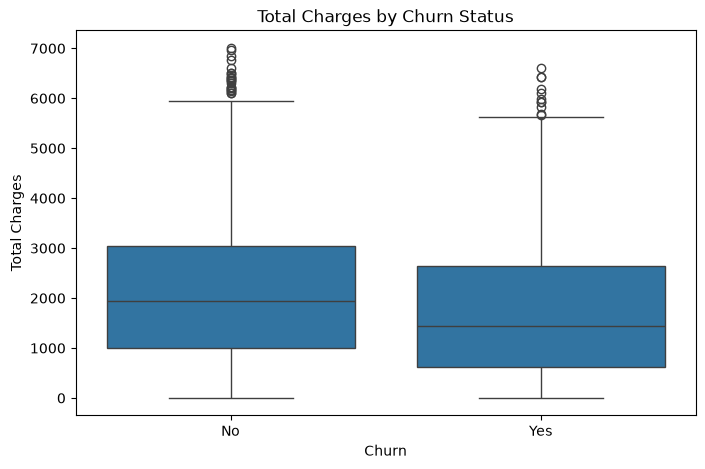

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()


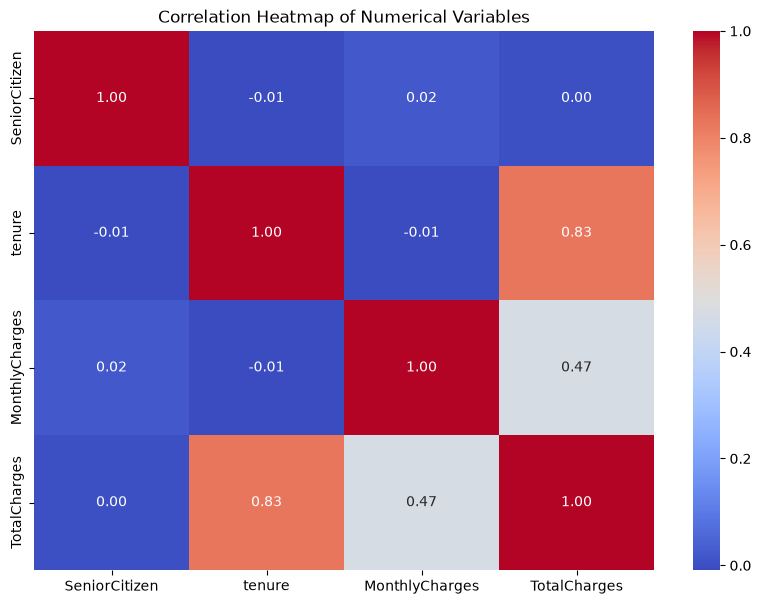

In [22]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

## 9. Outlier Detection

Use the IQR method to identify potential outliers in tenure, monthly charges, and total charges. Potential outliers are retained because they may represent genuine customer observations.


In [23]:
numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 4 outliers
TotalCharges: 28 outliers


## 10. Churn Reasons

Analyze the reported reasons provided for customers who churned.


In [24]:
churn_reasons = (
    df[df["Churn"] == "Yes"]["ChurnReason"]
    .value_counts()
)

print(churn_reasons)

ChurnReason
Price too high              369
Competitor offer            360
Network reliability         247
Poor customer service       240
Lack of support             195
Better package elsewhere    187
Service not needed          168
Billing issues               91
Not Available                 1
Name: count, dtype: int64


### Churn Reason Visualization

Visualize the reported churn reasons by frequency.


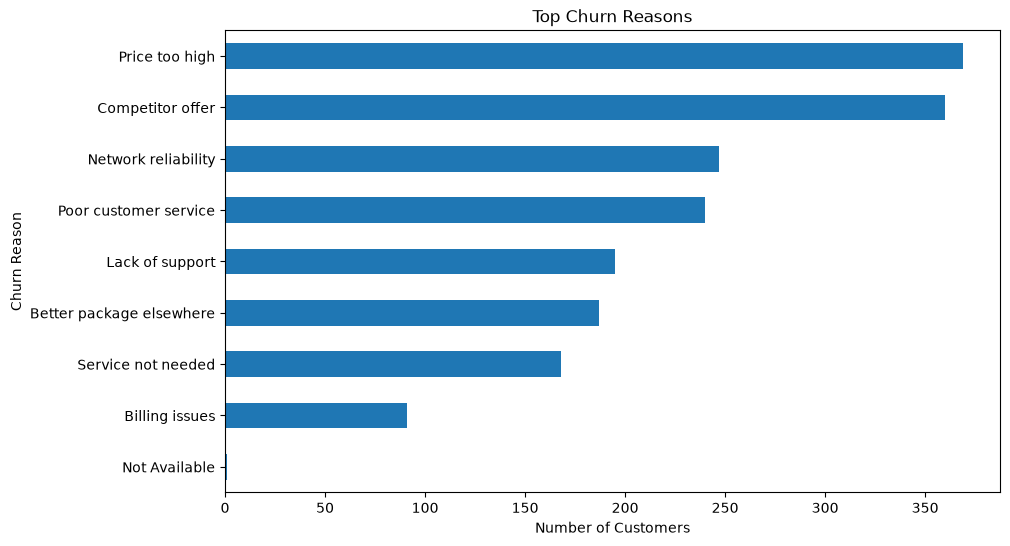

In [25]:
plt.figure(figsize=(10, 6))

churn_reasons.sort_values().plot(kind="barh")

plt.title("Top Churn Reasons")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Reason")
plt.show()

## 11. Churn Rate Analysis

Calculate churn percentages within important customer groups rather than relying only on raw churn counts.


In [26]:
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn_rate.round(2))

Churn              No    Yes
Contract                    
Month-to-month  65.10  34.90
One year        81.68  18.32
Two year        85.34  14.66


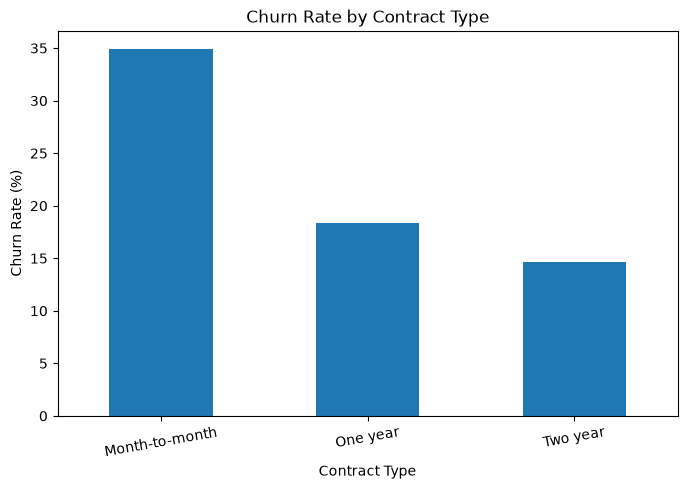

In [27]:
contract_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=10)
plt.show()

In [28]:
internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn_rate.round(2))


Churn               No    Yes
InternetService              
DSL              77.47  22.53
Fiber optic      64.50  35.50
No               86.35  13.65


### Churn Rate by Internet Service

Visualize the churn percentage within each internet-service category.


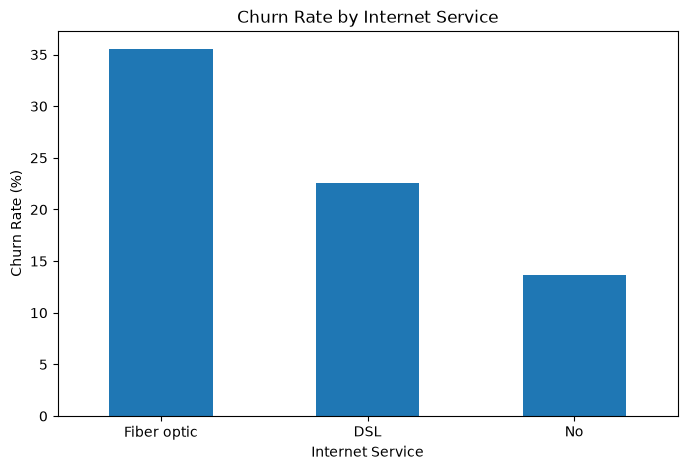

In [29]:
internet_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()


In [30]:
payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn_rate.round(2))

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  77.50  22.50
Credit card (automatic)    75.65  24.35
Electronic check           68.73  31.27
Mailed check               75.22  24.78


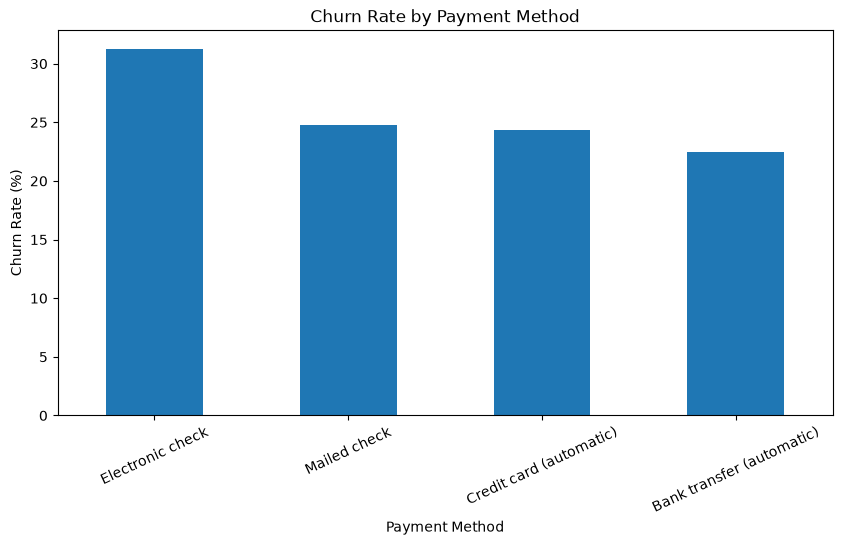

In [31]:
payment_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25)
plt.show()

### Churn Rate by Tech Support

Examine churn rates for customers according to their Tech Support status.


In [32]:
tech_support_churn_rate = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(tech_support_churn_rate.round(2))

Churn                   No    Yes
TechSupport                      
No                   69.07  30.93
No internet service  86.35  13.65
Yes                  71.84  28.16


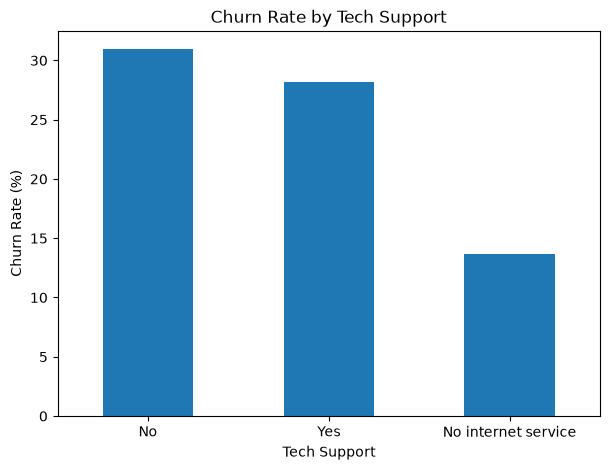

In [33]:
tech_support_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## 12. Churn Correlation with Numerical Variables

Encode churn as a binary flag (`0 = No`, `1 = Yes`) to examine numerical correlations with churn.


In [34]:
df["Churn_Flag"] = df["Churn"].map({"No": 0, "Yes": 1})

numeric_churn_corr = (
    df.select_dtypes(include=["int64", "float64"])
    .corr()["Churn_Flag"]
    .sort_values(ascending=False)
)

print(numeric_churn_corr.round(2))


Churn_Flag        1.00
MonthlyCharges    0.19
SeniorCitizen     0.05
TotalCharges     -0.11
tenure           -0.23
Name: Churn_Flag, dtype: float64


## 13. Churn Rate by Tenure Group

Group customers by tenure range to make the relationship between customer tenure and churn easier to interpret.


In [35]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)

tenure_churn_rate = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn_rate.round(2))

Churn           No    Yes
TenureGroup              
0-12         57.11  42.89
13-24        66.37  33.63
25-36        70.87  29.13
37-48        77.62  22.38
49-60        83.64  16.36
61-72        86.31  13.69


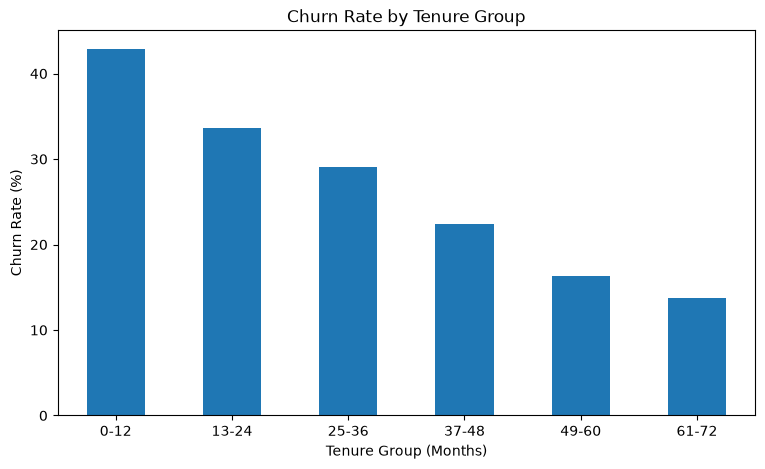

In [36]:
tenure_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## 14. Tenure and Monthly Charges Relationship

Use a scatter plot to examine monthly charges and tenure while distinguishing churn status.


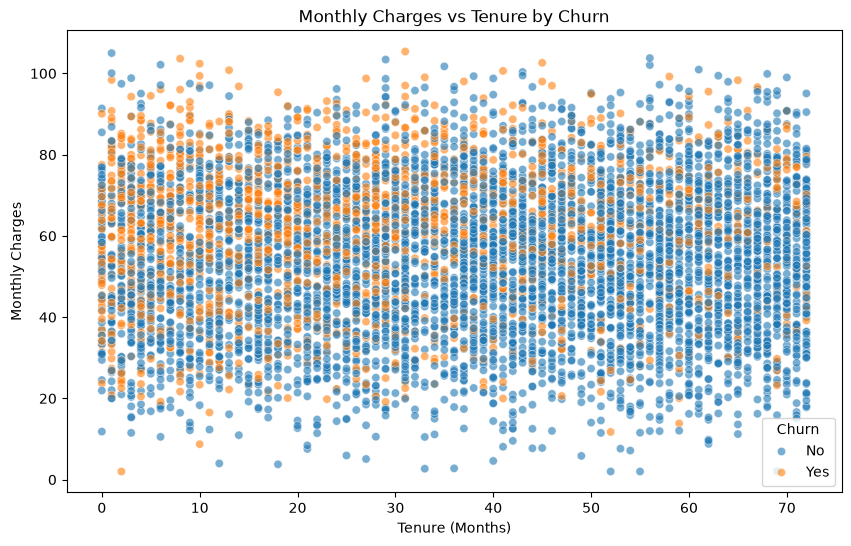

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Monthly Charges vs Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.show()

## 15. Churn Rate by Online Security

Compare churn rates based on Online Security service status.


In [38]:
online_security_churn_rate = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(online_security_churn_rate.round(2))

Churn                   No    Yes
OnlineSecurity                   
No                   69.31  30.69
No internet service  86.35  13.65
Yes                  71.39  28.61


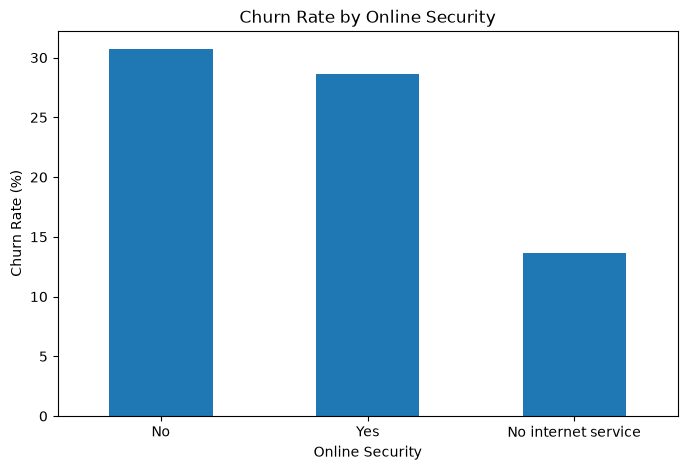

In [39]:
online_security_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## 16. Churn Rate by Senior Citizen Status

Compare churn rates between senior and non-senior customers.


In [40]:
senior_churn_rate = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn_rate.round(2))

Churn             No    Yes
SeniorCitizen              
0              74.54  25.46
1              68.55  31.45


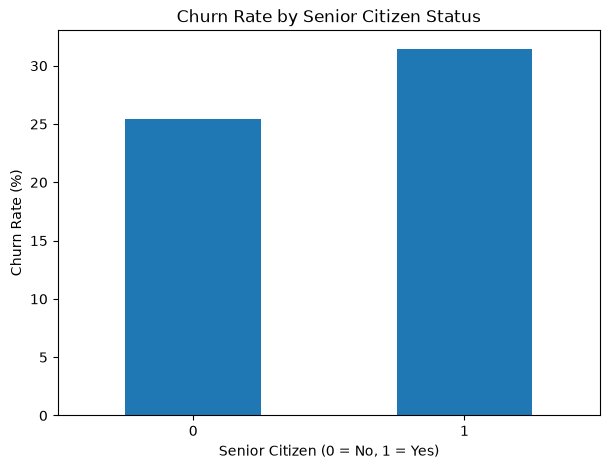

In [41]:
senior_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()


## 17. Key Churn Rate Summary

Create a compact table containing selected churn-rate results for the final report.


In [42]:
summary = pd.DataFrame({
    "Analysis": [
        "Overall Churn",
        "Month-to-month Contract",
        "One year Contract",
        "Two year Contract"
    ],
    "Churn Rate (%)": [
        (df["Churn"] == "Yes").mean() * 100,
        contract_churn_rate.loc["Month-to-month", "Yes"],
        contract_churn_rate.loc["One year", "Yes"],
        contract_churn_rate.loc["Two year", "Yes"]
    ]
})

print(summary.round(2))

                  Analysis  Churn Rate (%)
0            Overall Churn           26.38
1  Month-to-month Contract           34.90
2        One year Contract           18.32
3        Two year Contract           14.66


### Churn Reason Visualization

Visualize the reported churn reasons by frequency.


In [43]:
print("Overall Churn Rate:", round((df["Churn"] == "Yes").mean() * 100, 2), "%")

print("\nTop Churn Reasons:")
print(churn_reasons.head(5))

print("\nContract Churn Rate:")
print(contract_churn_rate["Yes"].round(2))

print("\nInternet Service Churn Rate:")
print(internet_churn_rate["Yes"].round(2))

print("\nPayment Method Churn Rate:")
print(payment_churn_rate["Yes"].round(2))

Overall Churn Rate: 26.38 %

Top Churn Reasons:
ChurnReason
Price too high           369
Competitor offer         360
Network reliability      247
Poor customer service    240
Lack of support          195
Name: count, dtype: int64

Contract Churn Rate:
Contract
Month-to-month    34.90
One year          18.32
Two year          14.66
Name: Yes, dtype: float64

Internet Service Churn Rate:
InternetService
DSL            22.53
Fiber optic    35.50
No             13.65
Name: Yes, dtype: float64

Payment Method Churn Rate:
PaymentMethod
Bank transfer (automatic)    22.50
Credit card (automatic)      24.35
Electronic check             31.27
Mailed check                 24.78
Name: Yes, dtype: float64


## 17. Key Churn Rate Summary

Create a compact table containing selected churn-rate results for the final report.


In [44]:
insight_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate",
        "Top Churn Reason",
        "Top Churn Reason Count"
    ],
    "Value": [
        len(df),
        (df["Churn"] == "Yes").sum(),
        round((df["Churn"] == "Yes").mean() * 100, 2),
        churn_reasons.index[0],
        churn_reasons.iloc[0]
    ]
})

display(insight_summary)

,Metric,Value
0,Total Customers,7043
1,Churned Customers,1858
2,Overall Churn Rate,26.38
3,Top Churn Reason,Price too high
4,Top Churn Reason Count,369


In [45]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER

pdf_file = "Telecom_Churn_Insight_Summary.pdf"

doc = SimpleDocTemplate(
    pdf_file,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

styles = getSampleStyleSheet()

title_style = styles["Title"]
title_style.alignment = TA_CENTER

story = []

story.append(Paragraph("Telecom Customer Churn — Insight Summary", title_style))
story.append(Spacer(1, 20))

# Key metrics
story.append(Paragraph("<b>Key Metrics</b>", styles["Heading2"]))

metrics_data = [
    ["Metric", "Value"],
    ["Total Customers", str(len(df))],
    ["Churned Customers", str((df["Churn"] == "Yes").sum())],
    ["Overall Churn Rate", f"{(df['Churn'] == 'Yes').mean() * 100:.2f}%"],
    ["Top Churn Reason", str(churn_reasons.index[0])],
    ["Top Churn Reason Count", str(churn_reasons.iloc[0])]
]

table = Table(metrics_data, colWidths=[250, 180])
table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
    ("PADDING", (0, 0), (-1, -1), 7),
]))

story.append(table)
story.append(Spacer(1, 20))

# Insights
story.append(Paragraph("<b>Key Insights</b>", styles["Heading2"]))

insights = [
    f"The dataset contains {len(df):,} customers, with {(df['Churn'] == 'Yes').sum():,} customers classified as churned.",
    
    f"The overall churn rate is {(df['Churn'] == 'Yes').mean() * 100:.2f}%.",
    
    f"The most frequently reported churn reason is '{churn_reasons.index[0]}', "
    f"with {churn_reasons.iloc[0]} customers.",
    
    "Contract type, internet service, payment method, tenure, and customer support-related services "
    "were analyzed to identify differences in churn rates.",
    
    "Monthly Charges and Total Charges were examined using boxplots, while numerical variables "
    "were analyzed using correlation analysis.",
    
    "Outlier analysis identified a small number of observations in MonthlyCharges and TotalCharges. "
    "These observations were retained because they may represent genuine customer behavior."
]

for insight in insights:
    story.append(Paragraph("• " + insight, styles["BodyText"]))
    story.append(Spacer(1, 8))

story.append(Spacer(1, 15))

story.append(
    Paragraph(
        "<b>Conclusion:</b> The EDA provides an overview of customer churn patterns, "
        "churn reasons, customer characteristics, service usage, and numerical relationships "
        "within the telecom dataset.",
        styles["BodyText"]
    )
)

doc.build(story)

print(f"PDF created successfully: {pdf_file}")

ModuleNotFoundError: No module named 'reportlab'